# Análisis exploratorio de datos (EDA)

In [1]:
# Importamos librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
from datetime import datetime
import plotly.express as px
import folium
import pingouin as pg
import plotly.graph_objects as go
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import kstest, jarque_bera
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

In [2]:
# importamos datos
filename = 'C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/\_8MachineLearning\proyecto_ml\datos\datos_oleaje.xlsx'
data = pd.read_excel(filename)

In [3]:
# Convertimos la fecha y hora al formato formato adecuado
data['date_time'] = pd.to_datetime(data['date_time'], format='%Y%m%d%H%M%S')

In [4]:
# Haciendo que el index sean las mismas fechas
data.index = data['date_time']

In [5]:
# Creando columna de inicio de mes
data['Start_Month'] = data['date_time'].dt.to_period('M').dt.to_timestamp()

In [6]:
# Creando columna de inicio de año
data['year'] = data['date_time'].dt.year

## 1. Introducción y contexto

Los datos utilizados en esta investigación son datos tomados por la constelación de satélites Sentinel-3, desarrollada por la Agencia Espacial Europea (ESA) como parte del Programa Copérnico. Los datos corresponden a las misiones Sentinel 3AB para la región del Reino Unido. En la tabla 1 se puede ver una descripción de las variables contenidas en el conjunto de datos.  Los registros se realizaron desde el 7 de abrid del 2016 hasta el 31 de diciembre del 2021.

### 1.1 Descripción de las variables



| Nombre de la Variable | Descripción                           | Unidad            |
|----------------------|-----------------------------------|------------------|
| lat                 | Latitud                            | Grados          |
| lon                 | Longitud                           | Grados          |
| Hs                  | Altura significativa del oleaje   | Metros          |
| T                   | Periodo                     | Segundos        |
| P                   | Potencial energético del oleaje   | kW/m            |
| uo                  | Componente u de la corriente      | m/s             |
| vo                  | Componente v de la corriente      | m/s             |
| mwd                 | Dirección media del oleaje        | Grados          |
| date_time           | Fecha y hora de la medición       | Fecha y hora    |

## 2. Análisis preliminar

### 2.1. Inspección general

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 133291 entries, 2016-04-14 21:16:02 to 2021-12-20 20:54:59
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   lat          133291 non-null  float64       
 1   lon          133291 non-null  float64       
 2   Hs           133291 non-null  float64       
 3   T            133291 non-null  float64       
 4   P            133291 non-null  float64       
 5   uo           133291 non-null  float64       
 6   vo           133291 non-null  float64       
 7   mwd          133291 non-null  float64       
 8   date_time    133291 non-null  datetime64[ns]
 9   Start_Month  133291 non-null  datetime64[ns]
 10  year         133291 non-null  int32         
dtypes: datetime64[ns](2), float64(8), int32(1)
memory usage: 11.7 MB


### 2.2. Estádisticas descriptivas

In [9]:
pd.options.display.float_format = '{:.4f}'.format
# Resumen estadístico
df_resumen = data.iloc[:, 2:8].describe()
df_resumen.loc['Kurtosis'] = data.iloc[:, 2:8].kurt()
df_resumen.loc['Skewness'] = data.iloc[:, 2:8].skew()
display(df_resumen)

,Hs,T,P,uo,vo,mwd
count,133291.0000,133291.0000,133291.0000,133291.0000,133291.0000,133291.0000
mean,1.4754,4.7114,10205.6716,0.0337,-0.0001,201.7403
std,0.9404,1.1128,16944.3120,0.3089,0.3475,113.2398
min,0.0000,0.4200,0.0000,-0.9200,-1.1000,0.1000
25%,0.8200,4.0700,1603.0000,-0.1700,-0.1800,92.1700
50%,1.2900,4.7500,4562.4100,0.0300,0.0100,224.7100
75%,1.9400,5.4000,11635.0750,0.2300,0.2000,299.6600
max,10.1700,21.0000,1055994.9800,1.3900,1.1500,359.8000
Kurtosis,2.0828,3.8286,163.8318,1.3148,0.2849,-1.1555
Skewness,1.1994,0.1735,6.7613,0.3779,-0.1688,-0.3891


## 3. Visualización de los datos

C:\Users\luis_\AppData\Local\Temp\ipykernel_9336\4232421614.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.iloc[:, 2:8].hist(ax=axes, bins=30, edgecolor='black', grid=False)


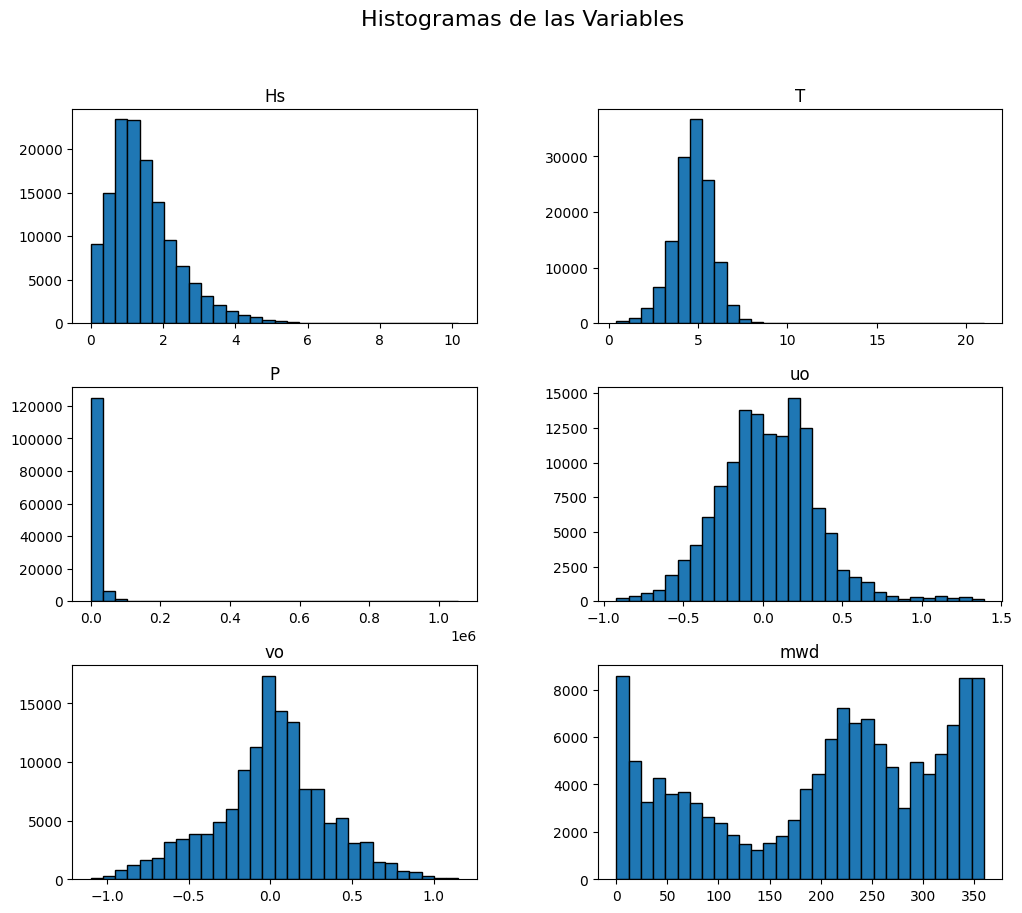

In [10]:
# Histogramas de las variables numéricas
fig, axes = plt.subplots(figsize=(12, 10))
data.iloc[:, 2:8].hist(ax=axes, bins=30, edgecolor='black', grid=False)
plt.suptitle('Histogramas de las Variables', fontsize=16)
plt.show()

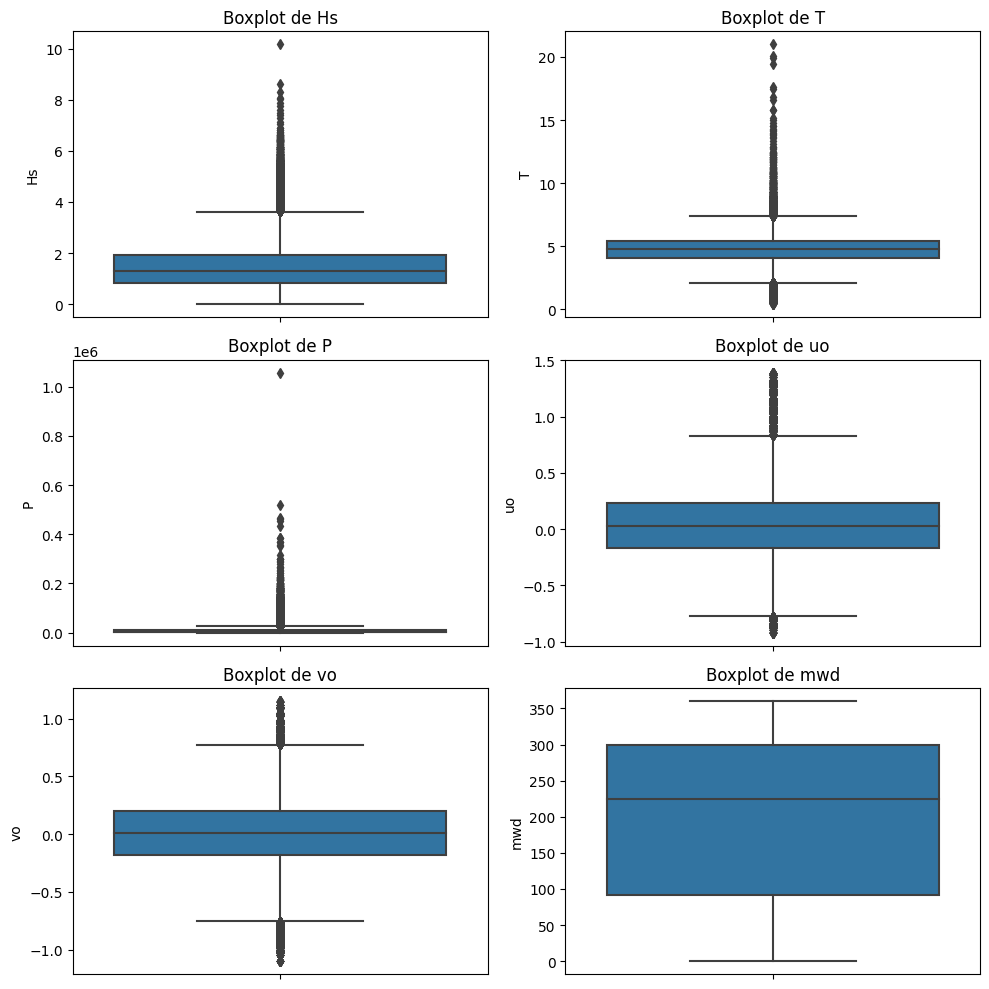

In [11]:
# Gráficos de caja y bigote

# Lista de variables numéricas
numeric_columns = ['Hs', 'T', 'P', 'uo', 'vo', 'mwd']

# Crear la figura con 3 filas y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

# Generar los boxplots en cada subgráfico
for ax, var in zip(axes.flat, numeric_columns):
    sns.boxplot(y=data[var], ax=ax)
    ax.set_title(f'Boxplot de {var}')

# Ajustar el diseño para mejor visualización
plt.tight_layout()
plt.show()

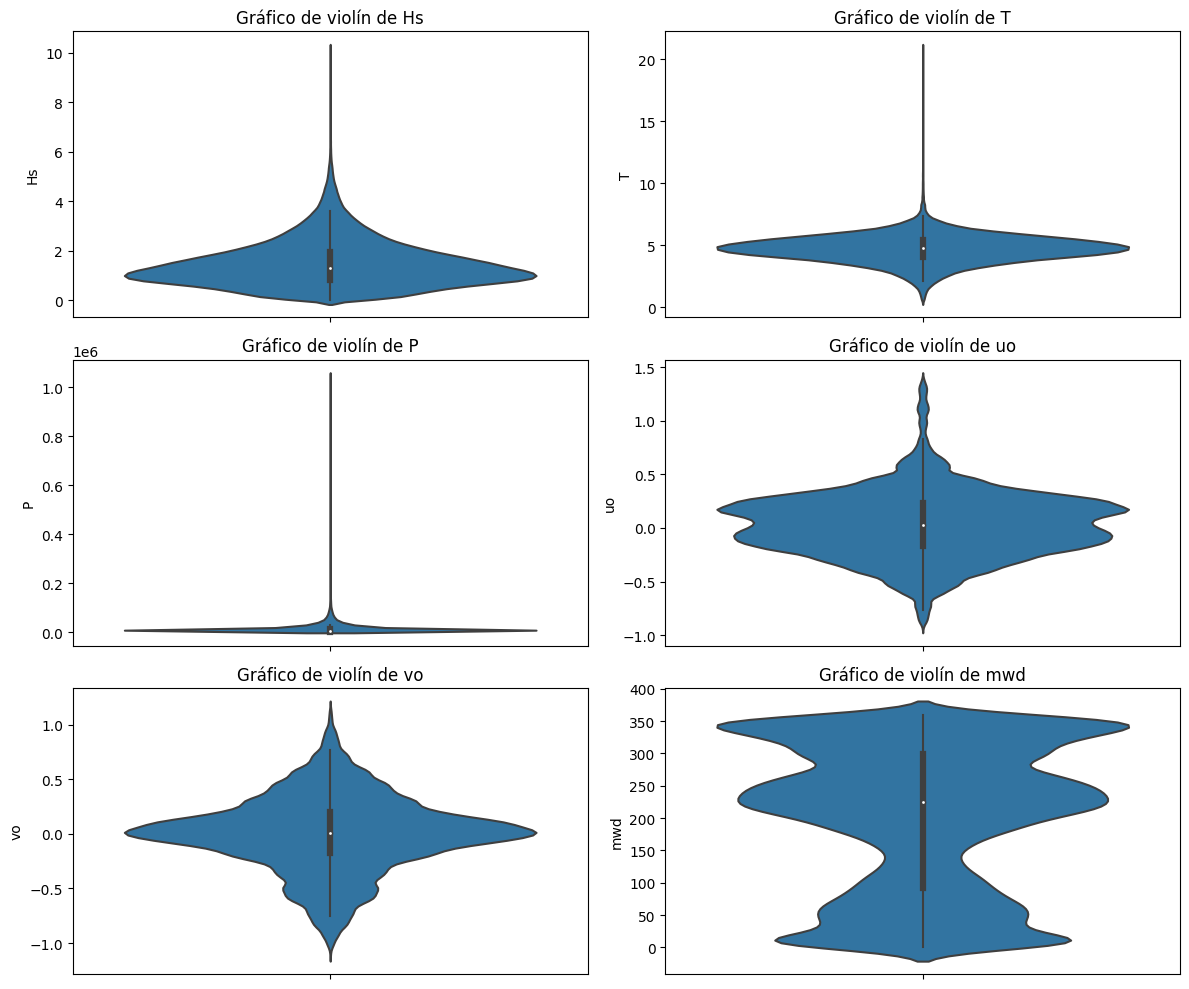

In [13]:
# Gráficos de violin

# Lista de variables numéricas
numeric_columns = ['Hs', 'T', 'P', 'uo', 'vo', 'mwd']

# Crear la figura con 3 filas y 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Generar los gráficos de violín en cada subgráfico
for ax, var in zip(axes.flat, numeric_columns):
    sns.violinplot(y=data[var], ax=ax)
    ax.set_title(f'Gráfico de violín de {var}')

# Ajustar el diseño para mejor visualización
plt.tight_layout()
plt.show()

## 4. Análisis de las variables

### 4.1 Análisis de correlación

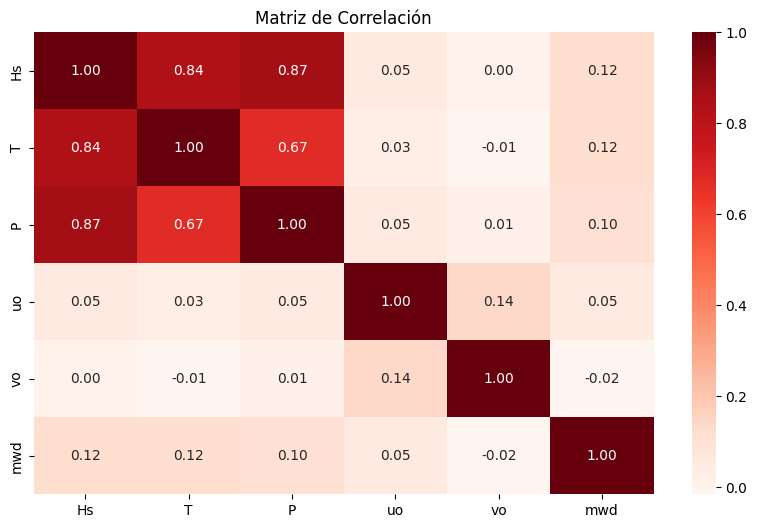

In [14]:
# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(data.drop(columns=['lat', 'lon', 'date_time', 'Start_Month', 'year']).corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

### 4.2 Pruebas de normalidad

In [17]:
# Pruebas de normalidad de Kolmogorov-Smirnov
ks_results = data.iloc[:, 2:8].apply(lambda x: kstest(x.dropna(), 'norm'))  # Estadístico y p-valor
ks_results

,Hs,T,P,uo,vo,mwd
0,0.5789,0.9664,0.9900,0.2765,0.2379,0.9813
1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [18]:
# Pruebas de normalidad de Jarque-Bera
jb_results = data.iloc[:, 2:8].apply(lambda x: jarque_bera(x.dropna()))  # Estadístico y p-valor
jb_results

,Hs,T,P,uo,vo,mwd
0,56044.7807,82068.3666,150072791.5776,12771.3964,1083.9528,10778.2187
1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### 4.3 Análisis de multicolinealidad

In [23]:
# Análisis de Multicolinealidad
X = data.drop(columns=['lat', 'lon', 'date_time', 'P', 'year', 'Start_Month']).dropna()

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data)

,Variable,VIF
0,Hs,7.0348
1,T,11.2323
2,uo,1.0379
3,vo,1.0202
4,mwd,3.9944


In [26]:
# Eliminando periodo
X = data.drop(columns=['lat', 'lon', 'date_time', 'P', 'T', 'year', 'Start_Month']).dropna()

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data)

,Variable,VIF
0,Hs,2.4380
1,uo,1.0370
2,vo,1.0202
3,mwd,2.4398


### 4.3 Análisis de valores extremos

In [ ]:
# Función para detectar valores atípicos usando Z-score
def detectar_outliers_zscore(data, columnas, umbral=3):
    outliers = {}
    
    for col in columnas:
        z_scores = zscore(data[col].dropna())  # Calcular Z-score, ignorando NaN
        outliers[col] = data.iloc[np.where(np.abs(z_scores) > umbral)][col]
    
    return outliers

# Aplicar el análisis a las variables numéricas
outliers_detectados_z = detectar_outliers_zscore(data, numeric_columns)

# Mostrar cantidad de valores atípicos por variable
outliers_resumen_z = {col: len(outliers_detectados_z[col]) for col in numeric_columns}

print("Cantidad de valores atípicos por variable (Z-score > 3):")
display(pd.DataFrame.from_dict(outliers_resumen_z, orient='index', columns=['Número de outliers']))

# Mostrar ejemplos de valores atípicos detectados
for col, outliers in outliers_detectados_z.items():
    if not outliers.empty:
        print(f"\nEjemplos de valores atípicos en {col}:")
        display(outliers.head(10))

Cantidad de valores atípicos por variable (Z-score > 3):


,Número de outliers
Hs,866
T,451
P,2011
uo,853
vo,0
mwd,0



Ejemplos de valores atípicos en Hs:


date_time
2016-06-15 21:08:58   5.07
2016-06-15 21:08:58   4.96
2016-06-15 21:08:58   5.04
2016-06-23 21:01:45   6.54
2016-06-23 21:01:46   5.25
2016-06-23 21:01:46   8.63
2016-06-23 21:01:46   6.13
2016-07-10 10:34:54   7.60
2016-11-17 20:51:16   5.30
2016-11-17 20:51:16   5.15
Name: Hs, dtype: float64


Ejemplos de valores atípicos en T:


date_time
2016-04-14 21:16:05    0.45
2016-04-08 10:45:53    0.48
2016-05-15 21:12:29    0.59
2016-05-11 21:16:07   10.87
2016-05-11 21:16:07   10.81
2016-05-11 21:16:07   10.27
2016-05-11 21:16:07   10.40
2016-05-11 21:16:07   11.83
2016-05-11 21:16:07   12.04
2016-05-11 21:16:07   10.89
Name: T, dtype: float64


Ejemplos de valores atípicos en P:


date_time
2016-06-15 21:08:58   183079.00
2016-06-15 21:08:58   129326.63
2016-06-15 21:08:58   173860.14
2016-06-15 21:08:58   181972.21
2016-06-23 21:01:45   124564.26
2016-06-23 21:01:45   262232.74
2016-06-23 21:01:45   101387.44
2016-06-23 21:01:46   121459.59
2016-06-23 21:01:46   154422.26
2016-06-23 21:01:46   465056.85
Name: P, dtype: float64


Ejemplos de valores atípicos en uo:


date_time
2016-06-09 10:38:32   1.16
2016-06-09 10:38:32   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
2016-06-09 10:38:33   1.16
Name: uo, dtype: float64

## 5. Análisis Temporal

### 5.1 Altura significativa del oleaje (Hs)

#### 5.1.1 Visualización de la serie

In [196]:
# Creando tabla de mes y promedio diario de hs
hs_monthly_avg = data.groupby('Start_Month')['Hs'].mean().reset_index()

Text(0, 0.5, 'velocidad del viento por mes')

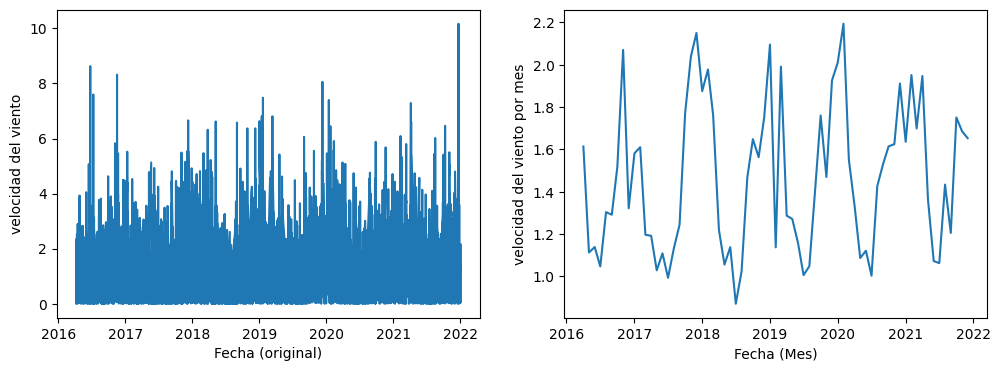

In [197]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de línea 1, serie sin agrupar
axes[0].plot(data['date_time'], data['Hs'])
axes[0].set_xlabel("Fecha (original)")
axes[0].set_ylabel("velocidad del viento")

# Gráfica de línea 2, serie agrupada por mes
axes[1].plot(hs_monthly_avg['Start_Month'], hs_monthly_avg['Hs'])
axes[1].set_xlabel("Fecha (Mes)")
axes[1].set_ylabel("velocidad del viento por mes")

#### 5.1.2 Análisis de patrones recurrentes

In [ ]:
# Creando tabla de fecha díaria y promedio diario de la altura de la ola
hs_daily_avg = data.groupby(data['date_time'].dt.date)['Hs'].mean().reset_index()

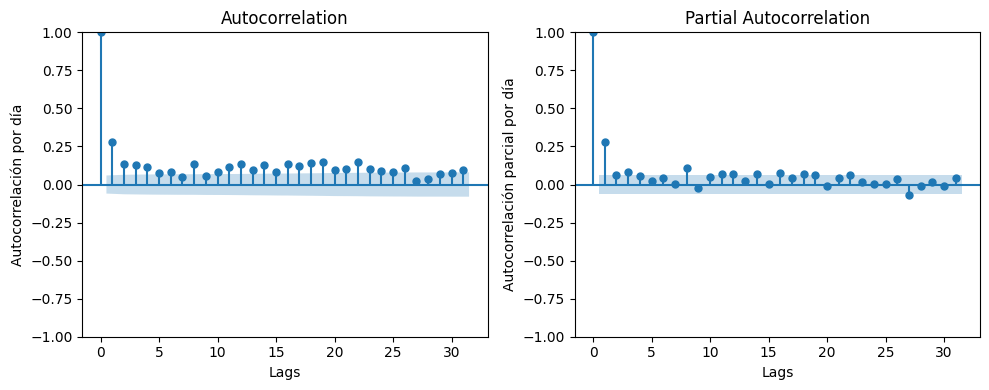

In [213]:
# Gráfica de autocorrelación y autocorrelación parcial de la serie

# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de autocorrelación
plot_acf(hs_daily_avg['Hs'], lags=31, ax=axes[0])
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Autocorrelación por día")

# Gráfica de autocorrelación parcial
plot_pacf(hs_daily_avg['Hs'], lags=31, ax=axes[1])
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Autocorrelación parcial por día")

plt.tight_layout()
plt.show()

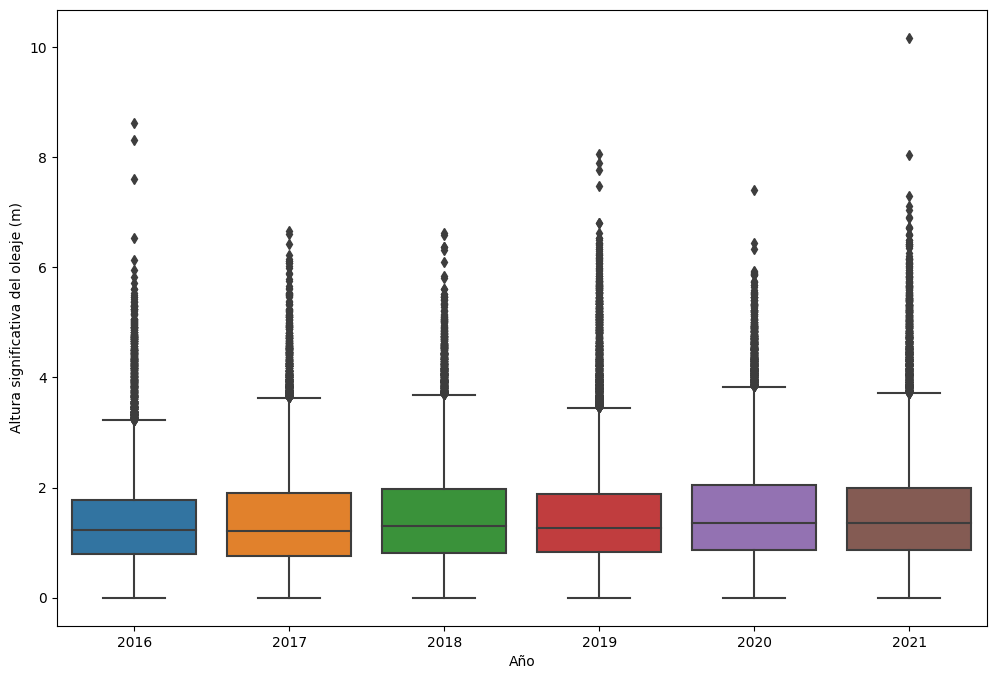

In [222]:
# Gráfica de caja y bigote
plt.figure(figsize=(12, 8))

sns.boxplot(x=data['year'], y=data['Hs'])
plt.xlabel("Año")
plt.ylabel("Altura significativa del oleaje (m)")
plt.show()

#### 5.1.3 Análisis de estacionariedad

In [224]:
# Prueba de Dickey-Fuller aumentado (ADF)
adf_result = adfuller(data['Hs'], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -25.245688959965875
p-value: 0.0
Critical Values: {'1%': -3.430399070107094, '5%': -2.8615616882782167, '10%': -2.566781543901176}


In [225]:
# Prueba de KPSS
kpss_result = kpss(data['Hs'], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.6856570222659727
p-value: 0.0148493616121843
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [226]:
# Aplicando diferenciación
first_order_diff = data['Hs'].diff(1)

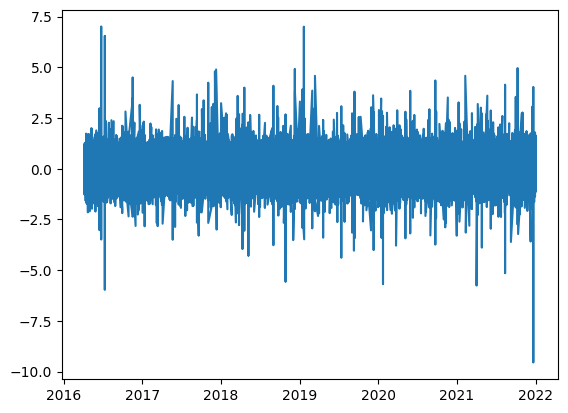

In [227]:
# Gráfica de la seria con datos diferenciados
plt.plot( first_order_diff.index, first_order_diff.values)

In [228]:
# Realizando prueba de ADF con los datos diferenciados

adf_result = adfuller(first_order_diff.iloc[1:], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -53.80092724818402
p-value: 0.0
Critical Values: {'1%': -3.4303990848401593, '5%': -2.8615616947899647, '10%': -2.5667815473671576}


In [229]:
# Realizando prueba de KPSS con los datos diferenciados
kpss_result = kpss(first_order_diff.iloc[1:], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.002067868529868625
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_8432\403408010.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




### 5.2 Periodo (T)

#### 5.2.1 Visualización de la serie

In [230]:
# Creando tabla de mes y promedio diario del periodo
T_monthly_avg = data.groupby('Start_Month')['T'].mean().reset_index()

Text(0, 0.5, 'velocidad del viento por mes')

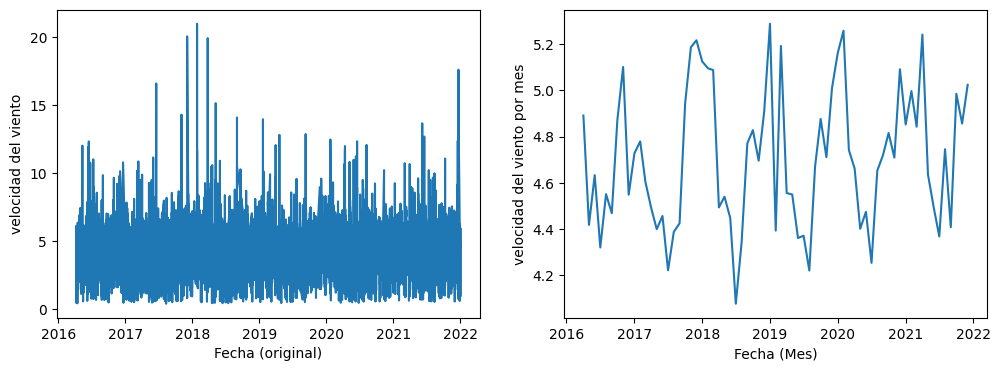

In [ ]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de línea 1, serie sin agrupar
axes[0].plot(data['date_time'], data['T'])
axes[0].set_xlabel("Fecha (original)")
axes[0].set_ylabel("Periodo")

# Gráfica de línea 2, serie agrupada por mes
axes[1].plot(T_monthly_avg['Start_Month'], T_monthly_avg['T'])
axes[1].set_xlabel("Fecha (Mes)")
axes[1].set_ylabel("Periodo por mes")

#### 5.1.2 Análisis de patrones recurrentes

In [ ]:
# Creando tabla de fecha díaria y promedio diario del periodo
T_daily_avg = data.groupby(data['date_time'].dt.date)['T'].mean().reset_index()

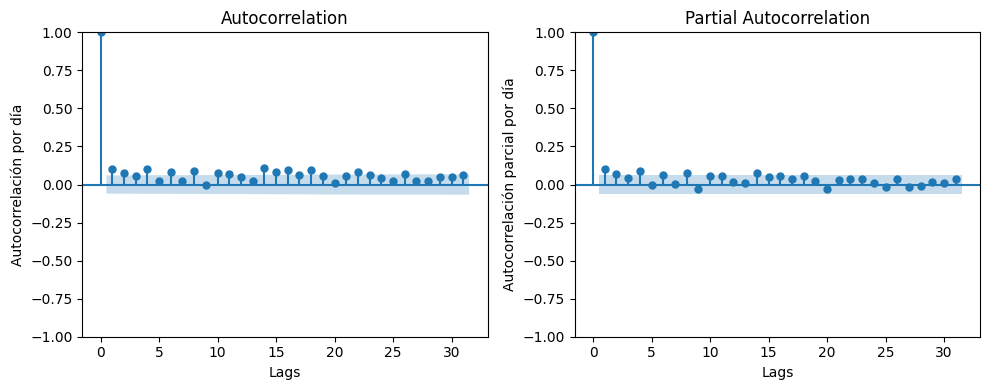

In [237]:
# Gráfica de autocorrelación y autocorrelación parcial de la serie

# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de autocorrelación
plot_acf(T_daily_avg['T'], lags=31, ax=axes[0])
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Autocorrelación por día")

# Gráfica de autocorrelación parcial
plot_pacf(T_daily_avg['T'], lags=31, ax=axes[1])
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Autocorrelación parcial por día")

plt.tight_layout()
plt.show()

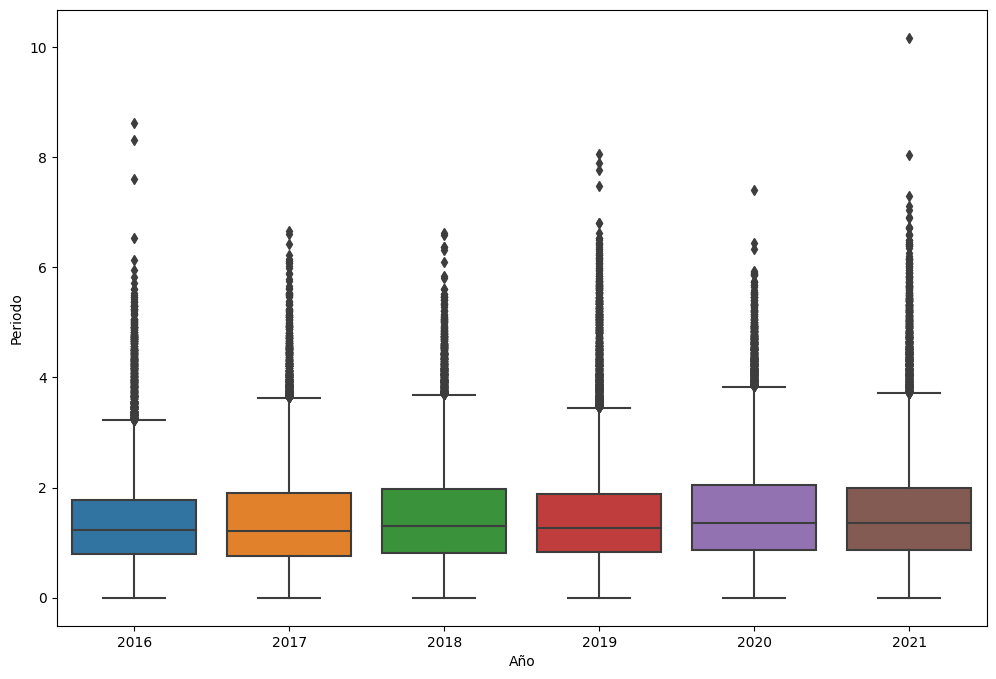

In [282]:
# Gráfica de caja y bigote
plt.figure(figsize=(12, 8))

sns.boxplot(x=data['year'], y=data['Hs'])
plt.xlabel("Año")
plt.ylabel("Periodo")
plt.show()

#### 5.2.3 Análisis de estacionariedad

In [242]:
# Prueba de Dickey-Fuller aumentado (ADF)
adf_result = adfuller(data['T'], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -32.15586531681992
p-value: 0.0
Critical Values: {'1%': -3.430399071211767, '5%': -2.861561688766462, '10%': -2.5667815441610524}


In [243]:
# Prueba de KPSS
kpss_result = kpss(data['T'], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.5680205776543259
p-value: 0.026346716744521187
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [244]:
# Aplicando diferenciación
first_order_diff = data['T'].diff(1)

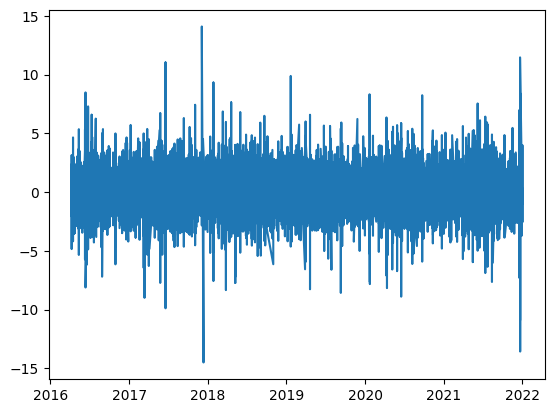

In [245]:
# Gráfica de la seria con datos diferenciados
plt.plot( first_order_diff.index, first_order_diff.values)

In [246]:
# Realizando prueba de ADF con los datos diferenciados

adf_result = adfuller(first_order_diff.iloc[1:], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -59.592493330829335
p-value: 0.0
Critical Values: {'1%': -3.4303990852085993, '5%': -2.8615616949528087, '10%': -2.566781547453834}


In [247]:
# Realizando prueba de KPSS con los datos diferenciados
kpss_result = kpss(first_order_diff.iloc[1:], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.0023626251740812764
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_8432\403408010.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




### 5.3 Potencial energético del oleaje (P)

#### 5.3.1 Visualización de la serie

In [248]:
# Creando tabla de mes y promedio diario de hs
P_monthly_avg = data.groupby('Start_Month')['P'].mean().reset_index()

Text(0, 0.5, 'Potencial por mes')

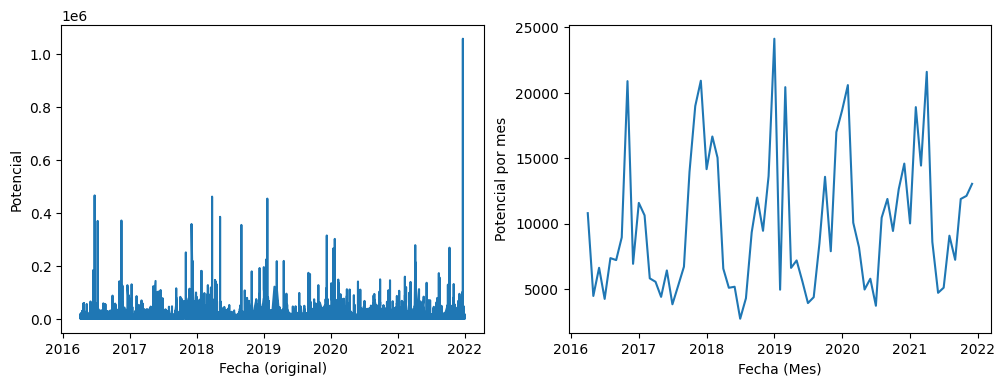

In [283]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de línea 1, serie sin agrupar
axes[0].plot(data['date_time'], data['P'])
axes[0].set_xlabel("Fecha (original)")
axes[0].set_ylabel("Potencial")

# Gráfica de línea 2, serie agrupada por mes
axes[1].plot(P_monthly_avg['Start_Month'], P_monthly_avg['P'])
axes[1].set_xlabel("Fecha (Mes)")
axes[1].set_ylabel("Potencial por mes")

#### 5.3.2 Análisis de patrones recurrentes

In [253]:
# Creando tabla de fecha díaria y promedio diario del potencial
P_daily_avg = data.groupby(data['date_time'].dt.date)['P'].mean().reset_index()

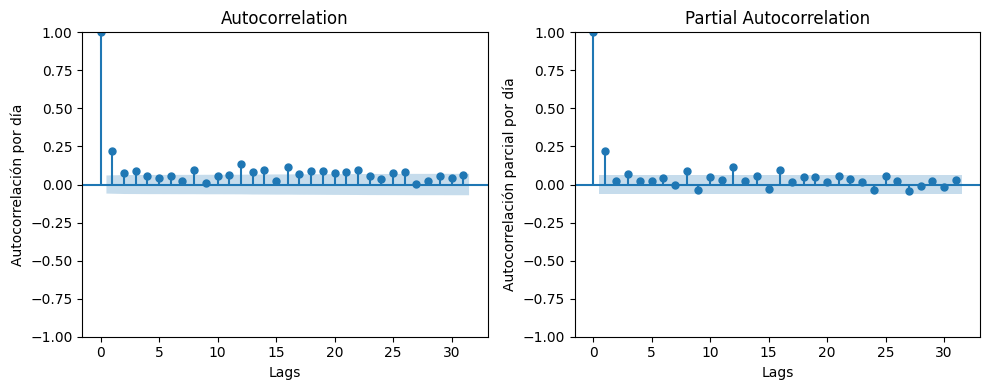

In [254]:
# Gráfica de autocorrelación y autocorrelación parcial de la serie

# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de autocorrelación
plot_acf(P_daily_avg['P'], lags=31, ax=axes[0])
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Autocorrelación por día")

# Gráfica de autocorrelación parcial
plot_pacf(P_daily_avg['P'], lags=31, ax=axes[1])
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Autocorrelación parcial por día")

plt.tight_layout()
plt.show()

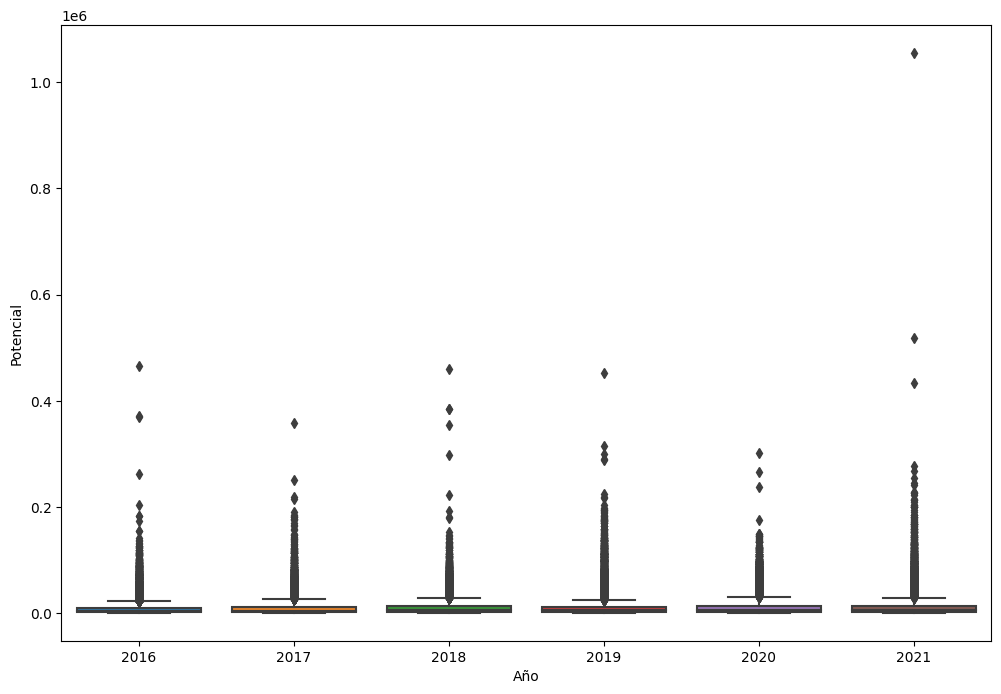

In [284]:
# Gráfica de caja y bigote
plt.figure(figsize=(12, 8))

sns.boxplot(x=data['year'], y=data['P'])
plt.xlabel("Año")
plt.ylabel("Potencial")
plt.show()

#### 5.3.3 Análisis de estacionariedad

In [256]:
# Prueba de Dickey-Fuller aumentado (ADF)
adf_result = adfuller(data['P'], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -24.86406629829458
p-value: 0.0
Critical Values: {'1%': -3.430399085577045, '5%': -2.861561695115655, '10%': -2.5667815475405114}


In [258]:
# Prueba de KPSS
kpss_result = kpss(data['P'], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.5450372469948535
p-value: 0.031523142568726695
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [259]:
# Aplicando diferenciación
first_order_diff = data['P'].diff(1)

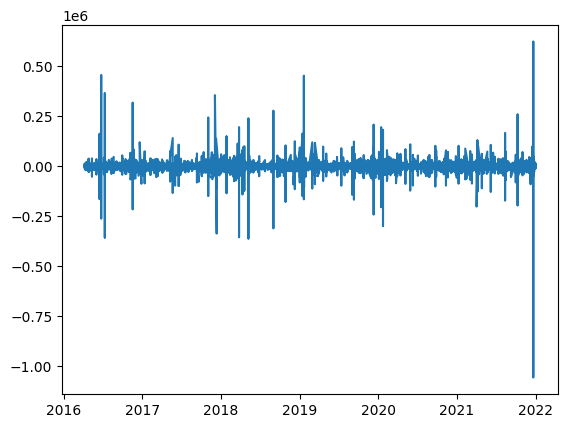

In [260]:
# Gráfica de la seria con datos diferenciados
plt.plot( first_order_diff.index, first_order_diff.values)

In [261]:
# Realizando prueba de ADF con los datos diferenciados

adf_result = adfuller(first_order_diff.iloc[1:], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -55.2806373106165
p-value: 0.0
Critical Values: {'1%': -3.4303990848401593, '5%': -2.8615616947899647, '10%': -2.5667815473671576}


In [262]:
# Realizando prueba de KPSS con los datos diferenciados
kpss_result = kpss(first_order_diff.iloc[1:], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.004930408504767011
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_8432\403408010.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




### 5.4 Corriente

#### 5.4.1 Visualización de la serie

In [ ]:
# Creando tabla de mes y promedio diario de ambas componentes de la corriente
u_monthly_avg = data.groupby('Start_Month')['uo'].mean().reset_index()
v_monthly_avg = data.groupby('Start_Month')['vo'].mean().reset_index()

Text(0, 0.5, 'componente u de la corriente por mes')

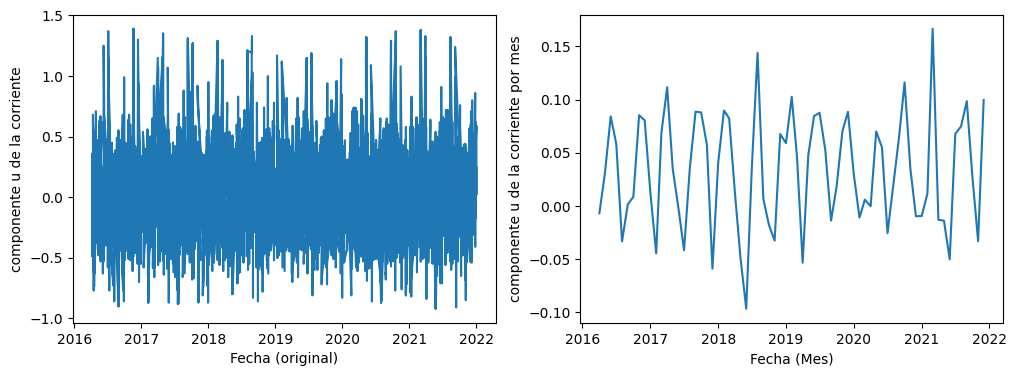

In [264]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de línea 1, serie sin agrupar
axes[0].plot(data['date_time'], data['uo'])
axes[0].set_xlabel("Fecha (original)")
axes[0].set_ylabel("componente u de la corriente")

# Gráfica de línea 2, serie agrupada por mes
axes[1].plot(u_monthly_avg['Start_Month'], u_monthly_avg['uo'])
axes[1].set_xlabel("Fecha (Mes)")
axes[1].set_ylabel("componente u de la corriente por mes")

Text(0, 0.5, 'componente v de la corriente por mes')

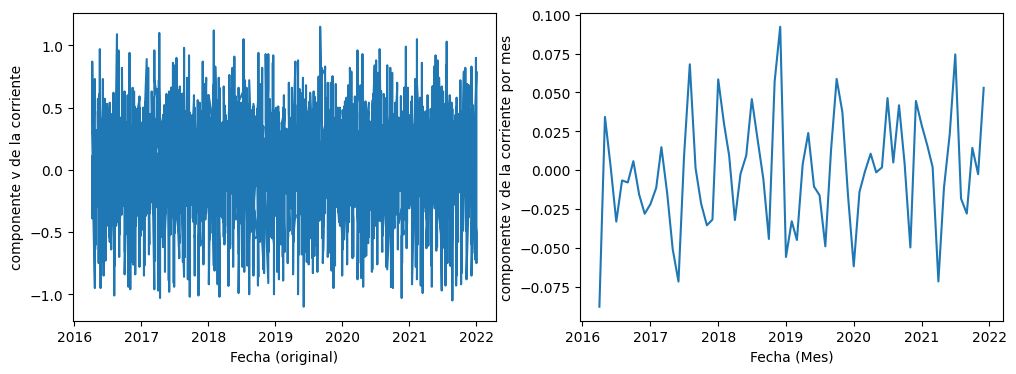

In [266]:
# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de línea 1, serie sin agrupar
axes[0].plot(data['date_time'], data['vo'])
axes[0].set_xlabel("Fecha (original)")
axes[0].set_ylabel("componente v de la corriente")

# Gráfica de línea 2, serie agrupada por mes
axes[1].plot(v_monthly_avg['Start_Month'], v_monthly_avg['vo'])
axes[1].set_xlabel("Fecha (Mes)")
axes[1].set_ylabel("componente v de la corriente por mes")

#### 5.4.2 Análisis de patrones recurrentes

In [267]:
# Creando tabla de fecha díaria y promedio diario de la corriente
u_daily_avg = data.groupby(data['date_time'].dt.date)['uo'].mean().reset_index()
v_daily_avg = data.groupby(data['date_time'].dt.date)['vo'].mean().reset_index()

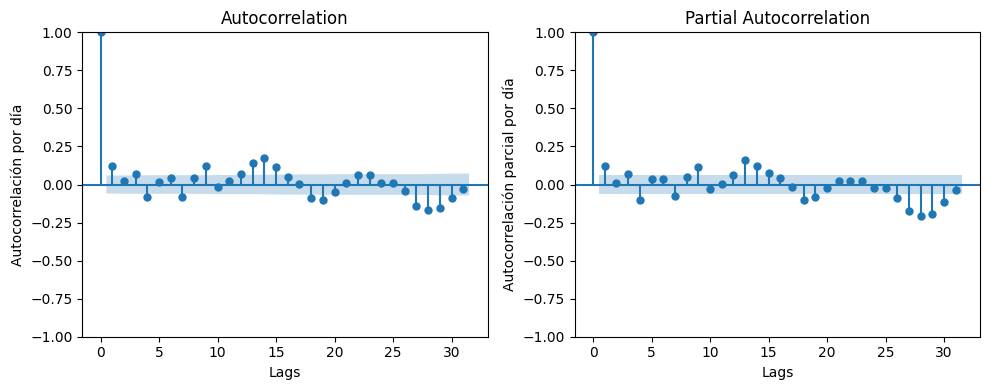

In [269]:
# Gráfica de autocorrelación y autocorrelación parcial de la serie

# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de autocorrelación
plot_acf(u_daily_avg['uo'], lags=31, ax=axes[0])
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Autocorrelación por día")

# Gráfica de autocorrelación parcial
plot_pacf(u_daily_avg['uo'], lags=31, ax=axes[1])
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Autocorrelación parcial por día")

plt.tight_layout()
plt.show()

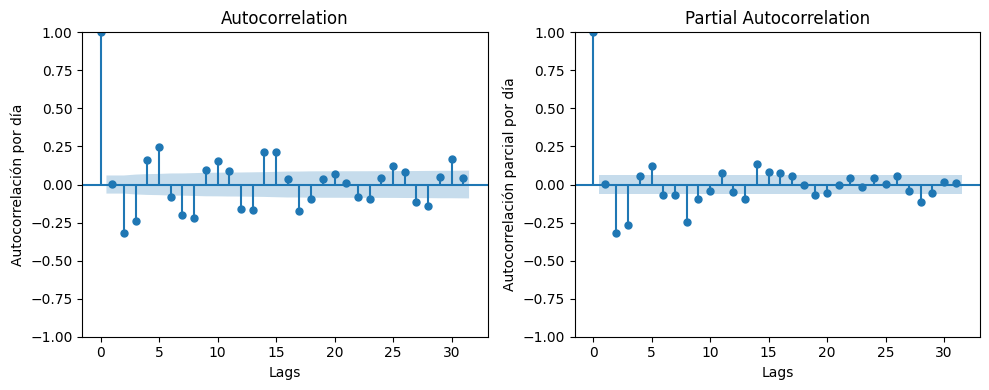

In [271]:
# Gráfica de autocorrelación y autocorrelación parcial de la serie

# Creo una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfica de autocorrelación
plot_acf(v_daily_avg['vo'], lags=31, ax=axes[0])
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Autocorrelación por día")

# Gráfica de autocorrelación parcial
plot_pacf(v_daily_avg['vo'], lags=31, ax=axes[1])
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Autocorrelación parcial por día")

plt.tight_layout()
plt.show()

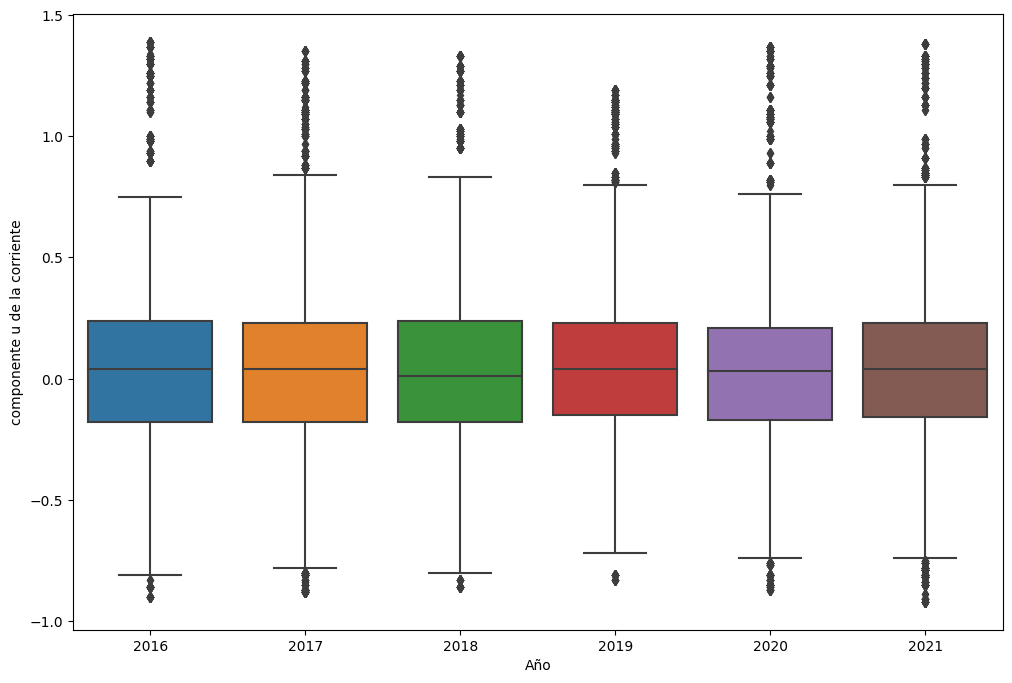

In [272]:
# Gráfica de caja y bigote
plt.figure(figsize=(12, 8))

sns.boxplot(x=data['year'], y=data['uo'])
plt.xlabel("Año")
plt.ylabel("componente u de la corriente")
plt.show()

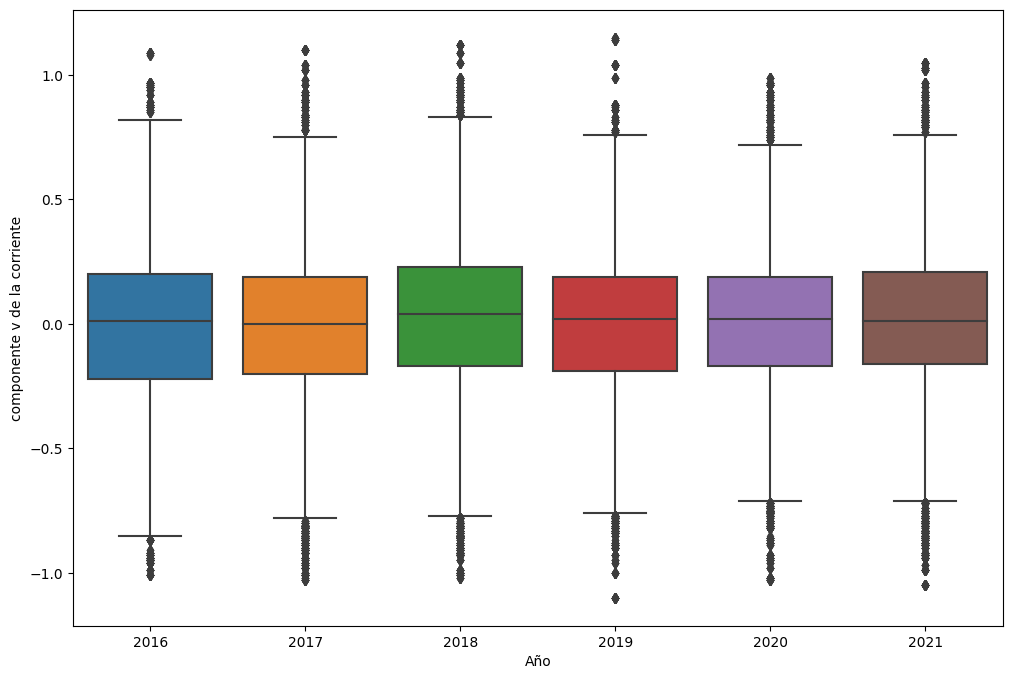

In [273]:
# Gráfica de caja y bigote
plt.figure(figsize=(12, 8))

sns.boxplot(x=data['year'], y=data['vo'])
plt.xlabel("Año")
plt.ylabel("componente v de la corriente")
plt.show()

#### 5.4.3 Análisis de estacionariedad

In [ ]:
# Prueba de Dickey-Fuller aumentado (ADF) para la componente u
adf_result = adfuller(data['uo'], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -31.2225408612443
p-value: 0.0
Critical Values: {'1%': -3.430399084471725, '5%': -2.8615616946271234, '10%': -2.566781547280483}


In [ ]:
# Prueba de KPSS para la componente u
kpss_result = kpss(data['uo'], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.024877587318428786
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_8432\4121163620.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [ ]:
# Prueba de Dickey-Fuller aumentado (ADF) para la componente v
adf_result = adfuller(data['vo'], autolag='AIC')

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -31.772678062471805
p-value: 0.0
Critical Values: {'1%': -3.4303990870508825, '5%': -2.861561695767064, '10%': -2.5667815478872344}


In [ ]:
# Prueba de KPSS para la componente v
kpss_result = kpss(data['vo'], regression='c', nlags="auto")

# Print the results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:", kpss_result[3])

KPSS Statistic: 0.07469873911311779
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\luis_\AppData\Local\Temp\ipykernel_8432\3366578382.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




## 6. Análisis Espacial

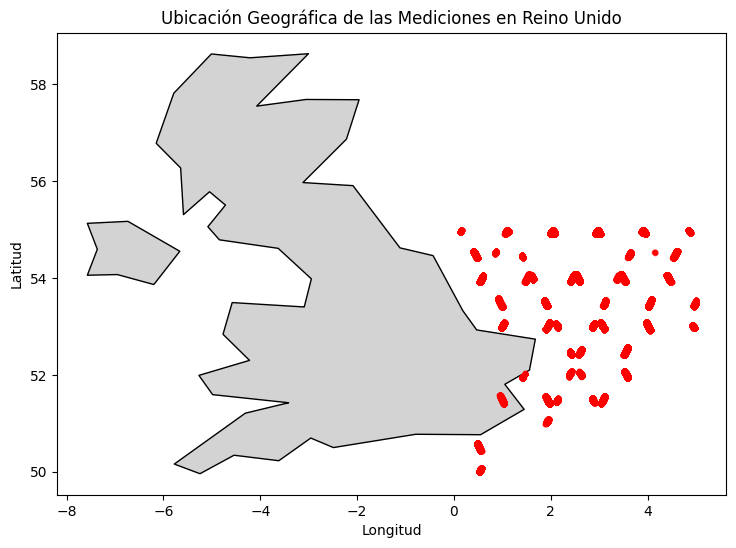

In [28]:
# Mapa de puntos con geopandas (solo Reino Unido)
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
uk = world[world['ADMIN'] == "United Kingdom"]
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.lon, data['lat']))

fig, ax = plt.subplots(figsize=(10, 6))
uk.plot(ax=ax, color='lightgray', edgecolor='black')
gdf.plot(ax=ax, marker='o', markersize=10, color='red', alpha=0.6)
plt.title('Ubicación Geográfica de las Mediciones en Reino Unido')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

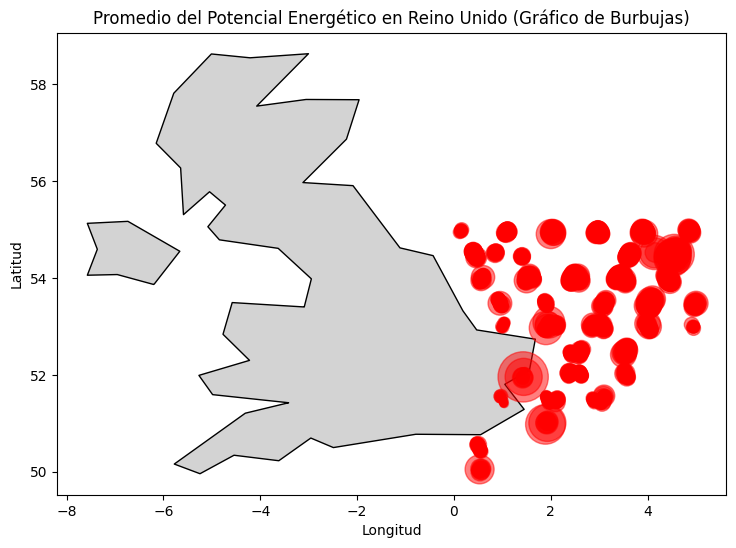

In [ ]:
# Gráfico de burbujas basado en el promedio del potencial energético
mean_potential = data.groupby(['lat', 'lon'])['P'].mean().reset_index()
gdf_potential = gpd.GeoDataFrame(mean_potential, geometry=gpd.points_from_xy(mean_potential.lon, mean_potential['lat']))

fig, ax = plt.subplots(figsize=(10, 6))
uk.plot(ax=ax, color='lightgray', edgecolor='black')
gdf_potential.plot(ax=ax, markersize=gdf_potential['P']/90, color='red', alpha=0.5)
plt.title('Promedio del Potencial Energético del oleaje en Reino Unido (Gráfico de Burbujas)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

In [106]:
# Mapa interactivo con Folium
m = folium.Map(location=[55.0, -3.0], zoom_start=6)

# Agregar puntos al mapa interactivo
for _, row in data.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
    ).add_to(m)

# Guardar mapa interactivo en un archivo HTML
m.save("mapa_interactivo.html")
print("Mapa interactivo guardado como 'mapa_interactivo.html'")

Mapa interactivo guardado como 'mapa_interactivo.html'


In [48]:
# Mapa interactivo con Folium y gráfico de burbujas por potencial promedio
m = folium.Map(location=[55.0, -3.0], zoom_start=6)

# Agregar burbujas al mapa interactivo según el potencial promedio
for _, row in mean_potential.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['P'] / 2000,  # Ajuste de escala para el tamaño de la burbuja
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
    ).add_to(m)

# Guardar mapa interactivo en un archivo HTML
m.save("mapa_interactivo_burbujas.html")
print("Mapa interactivo con burbujas guardado como 'mapa_interactivo_burbujas.html'")

Mapa interactivo con burbujas guardado como 'mapa_interactivo_burbujas.html'


In [58]:
# Gráfico de burbujas con Plotly basado en el potencial promedio por localización
fig = px.scatter_geo(mean_potential,
                     lat='lat',
                     lon='lon',
                     size='P',
                     hover_name='lat',
                     size_max=20,
                     title='Mapa de Burbujas del Potencial Energético del oleaje en el Reino Unido')

fig.update_geos(
    center={'lat': 55.0, 'lon': -3.0},
    projection_scale=6
)
fig.show()